In [1]:
import numpy as np
with open('x_65dims.npy', 'rb') as f:
    X = np.load(f)

In [2]:
import sys
sys.path.insert(1, "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod")

import tod.corpus
import tod.outliers
import tod.clustering
import tod.plotting

corpus = tod.corpus.Corpus(
    treebank_path="/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master",
    grew_pattern="pattern {X[upos=ADV]} without {X[InIdiom=Yes];X[Idiom=Yes]}",
    patterns_text_file="../3. probability_matrix/patterns_adv.txt",
    matrix_type="coverage"
)

connected to port: 60959


Number of matches after filtering: 11701


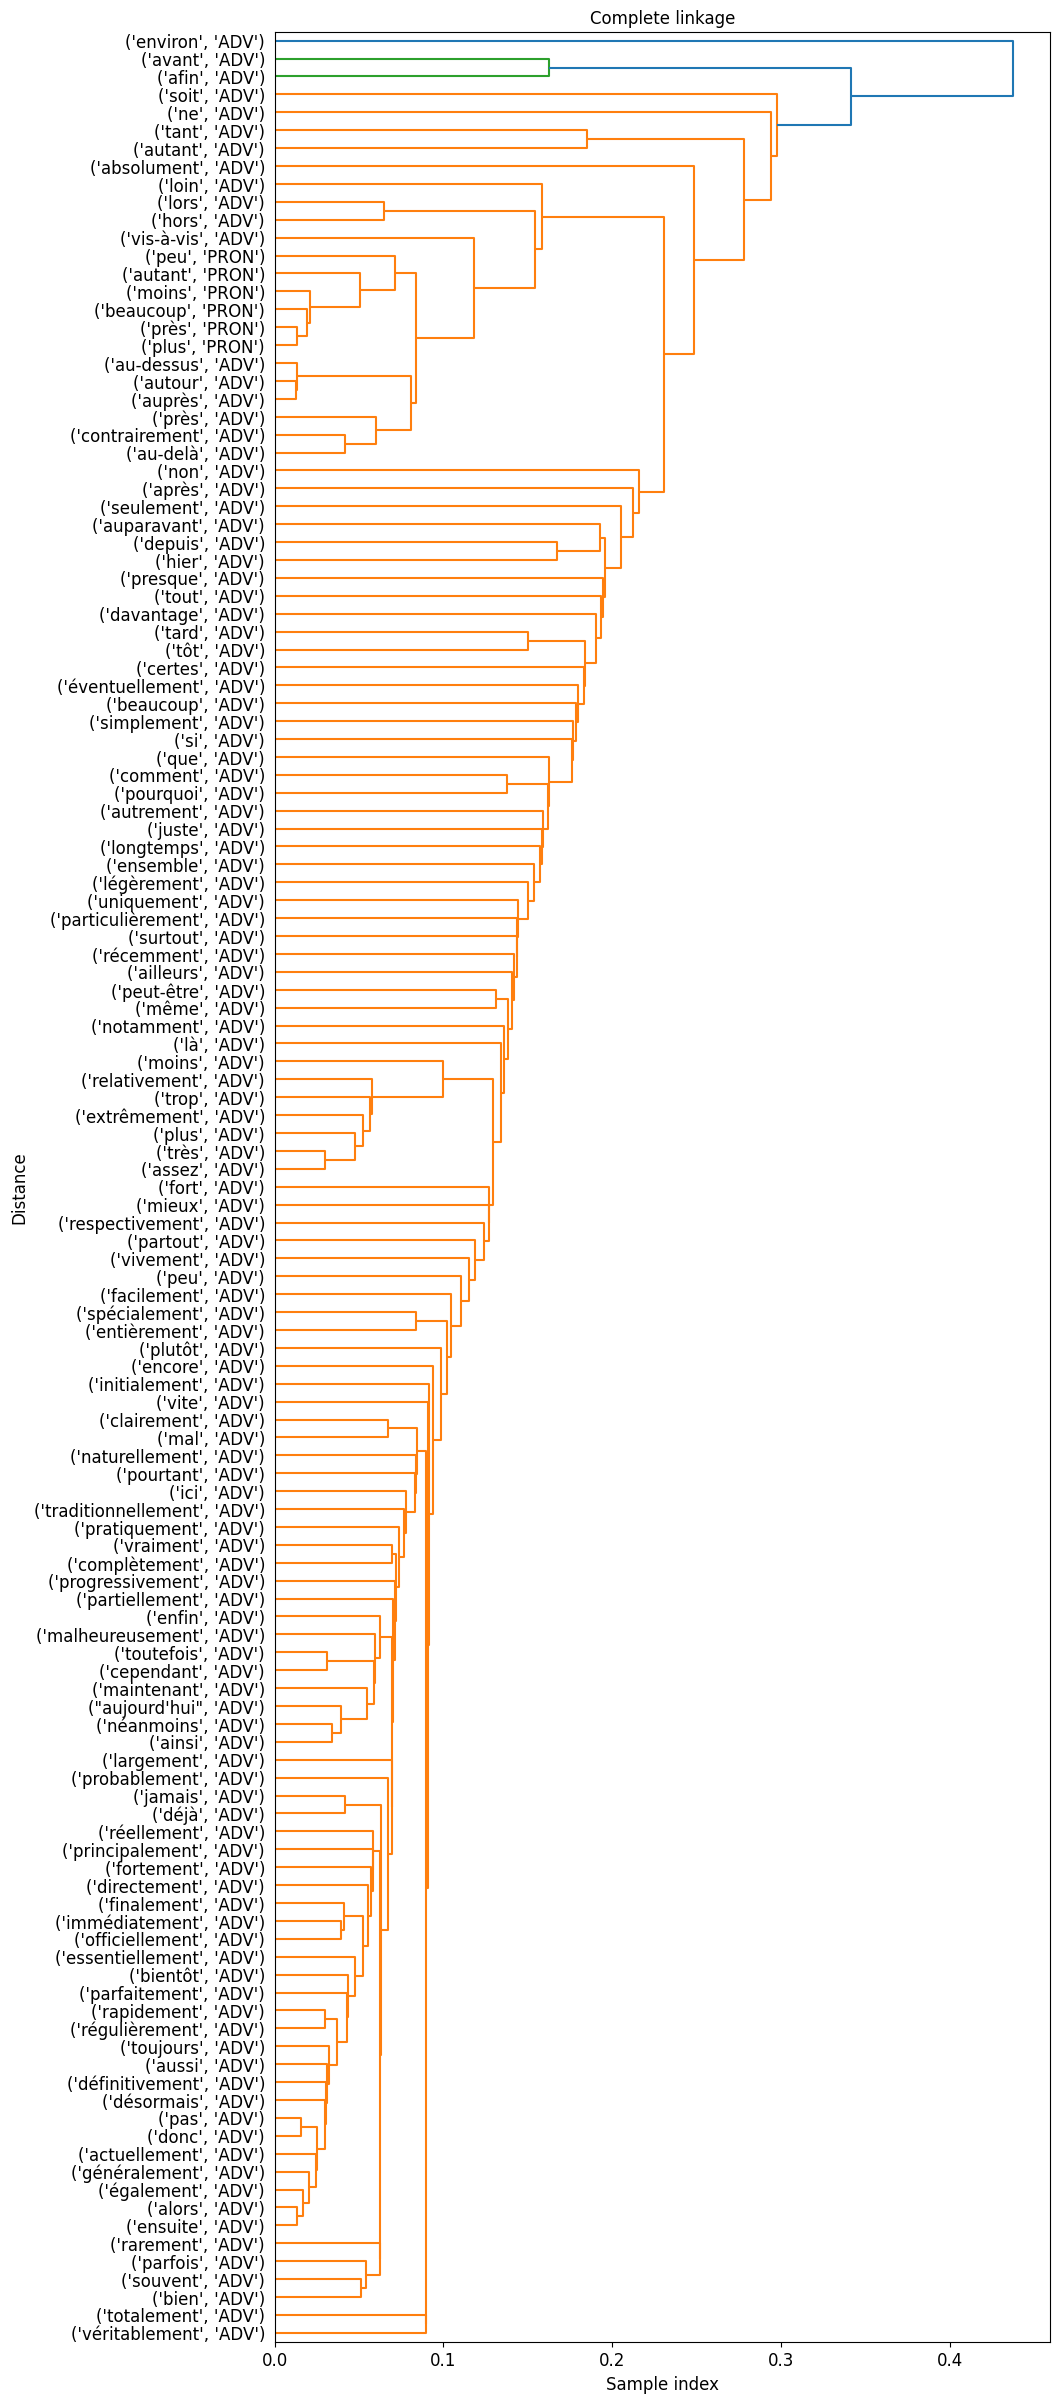

In [6]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib as plt
import matplotlib.pyplot as plt

distance_matrix = pdist(X, metric="cosine")
linked = linkage(
            distance_matrix, method="single", optimal_ordering=True
        ) 

plt.figure(figsize=(10, 30))

dn = dendrogram(linked,
                orientation='right',
                labels=[corpus.idx2lexunit(i) for i in range(X.shape[0])],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Complete linkage', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

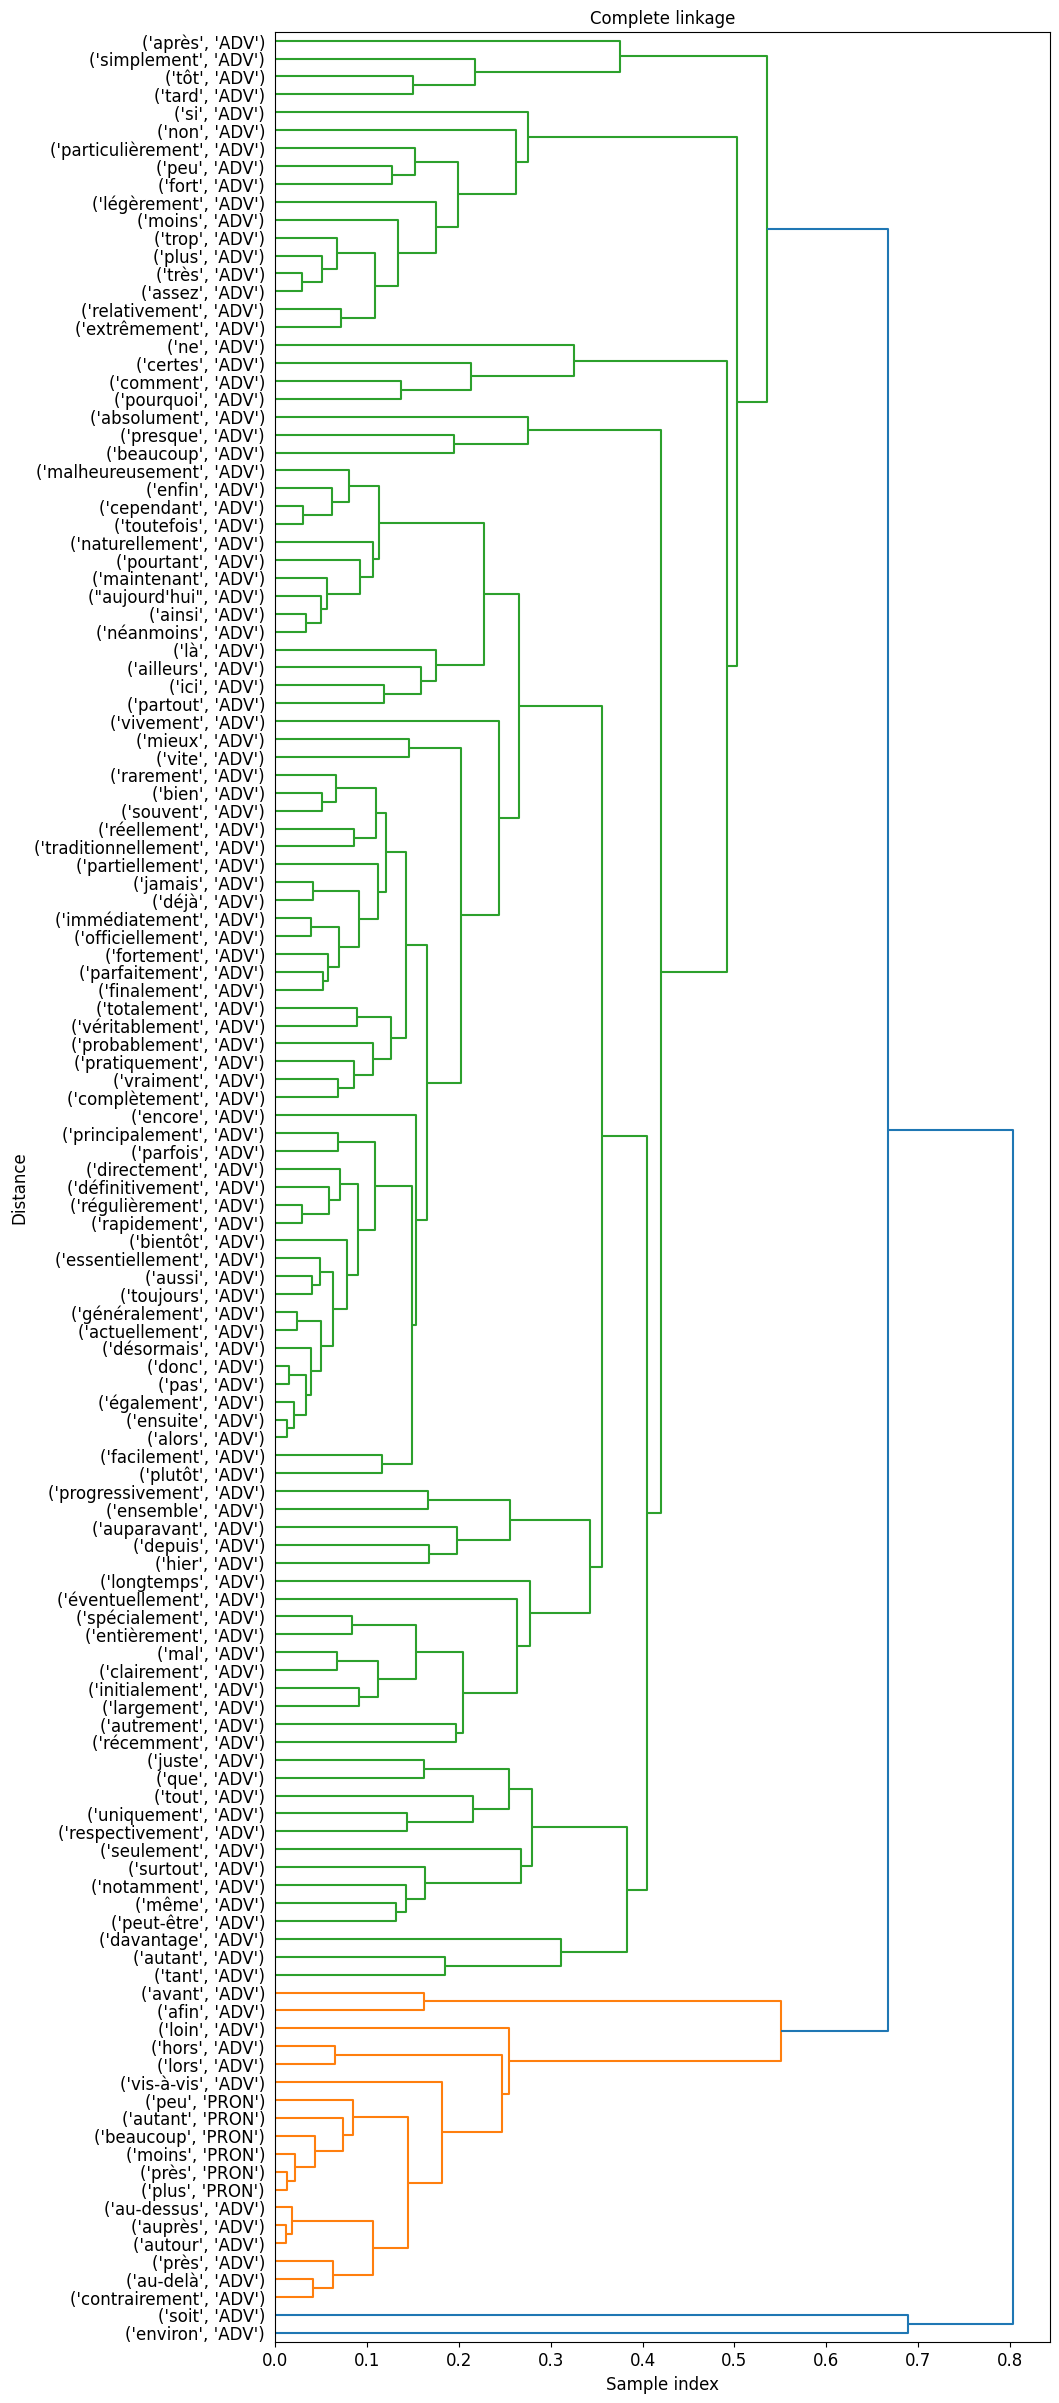

In [7]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib as plt
import matplotlib.pyplot as plt

distance_matrix = pdist(X, metric="cosine")
linked = linkage(
            distance_matrix, method="average", optimal_ordering=True
        ) 

plt.figure(figsize=(10, 30))

dn = dendrogram(linked,
                orientation='right',
                labels=[corpus.idx2lexunit(i) for i in range(X.shape[0])],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Complete linkage', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

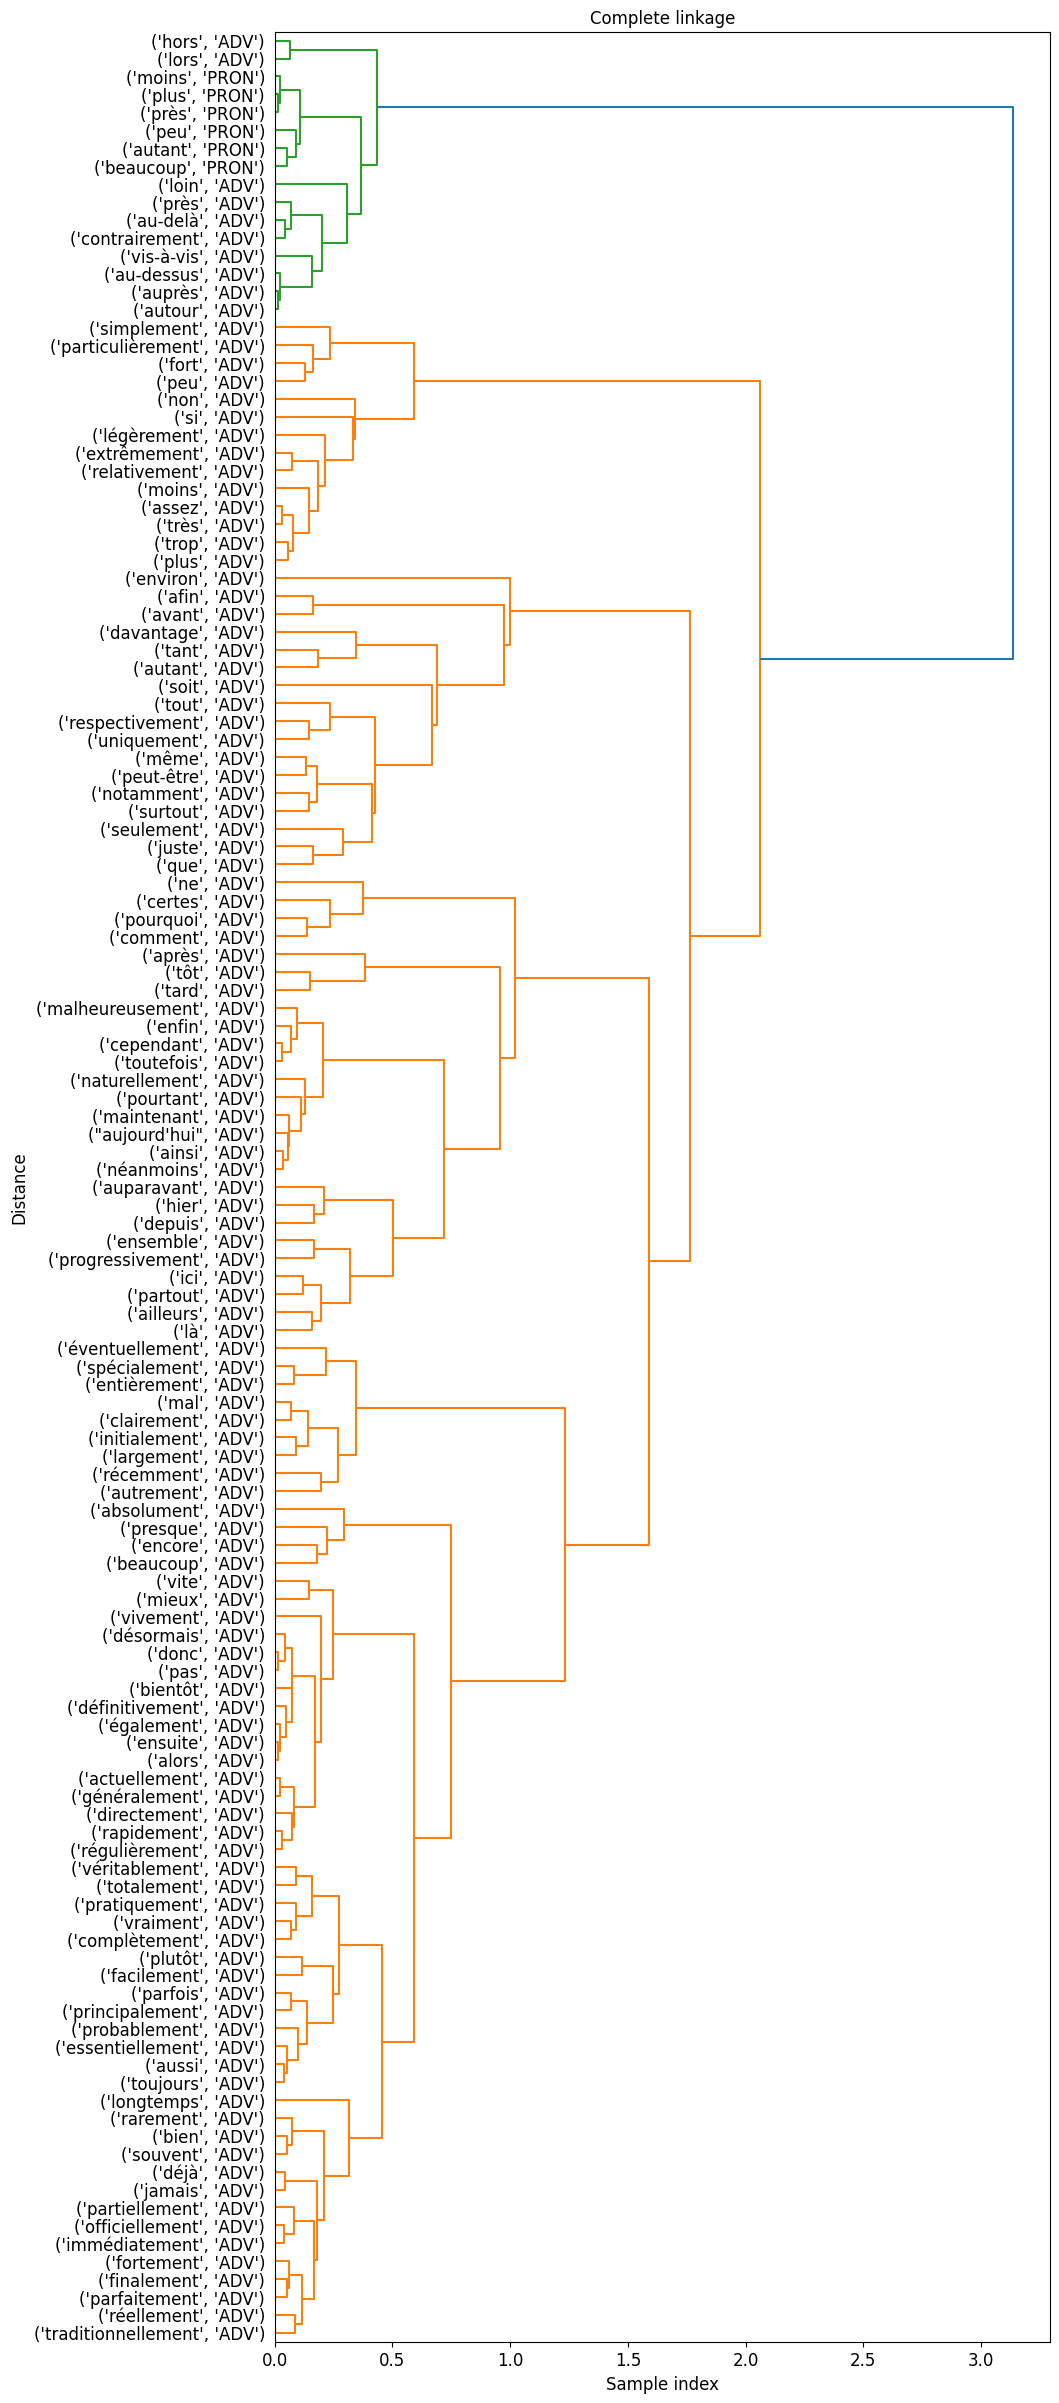

In [8]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib as plt
import matplotlib.pyplot as plt

distance_matrix = pdist(X, metric="cosine")
linked = linkage(
            distance_matrix, method="ward", optimal_ordering=True
        ) 

plt.figure(figsize=(10, 30))

dn = dendrogram(linked,
                orientation='right',
                labels=[corpus.idx2lexunit(i) for i in range(X.shape[0])],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Complete linkage', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

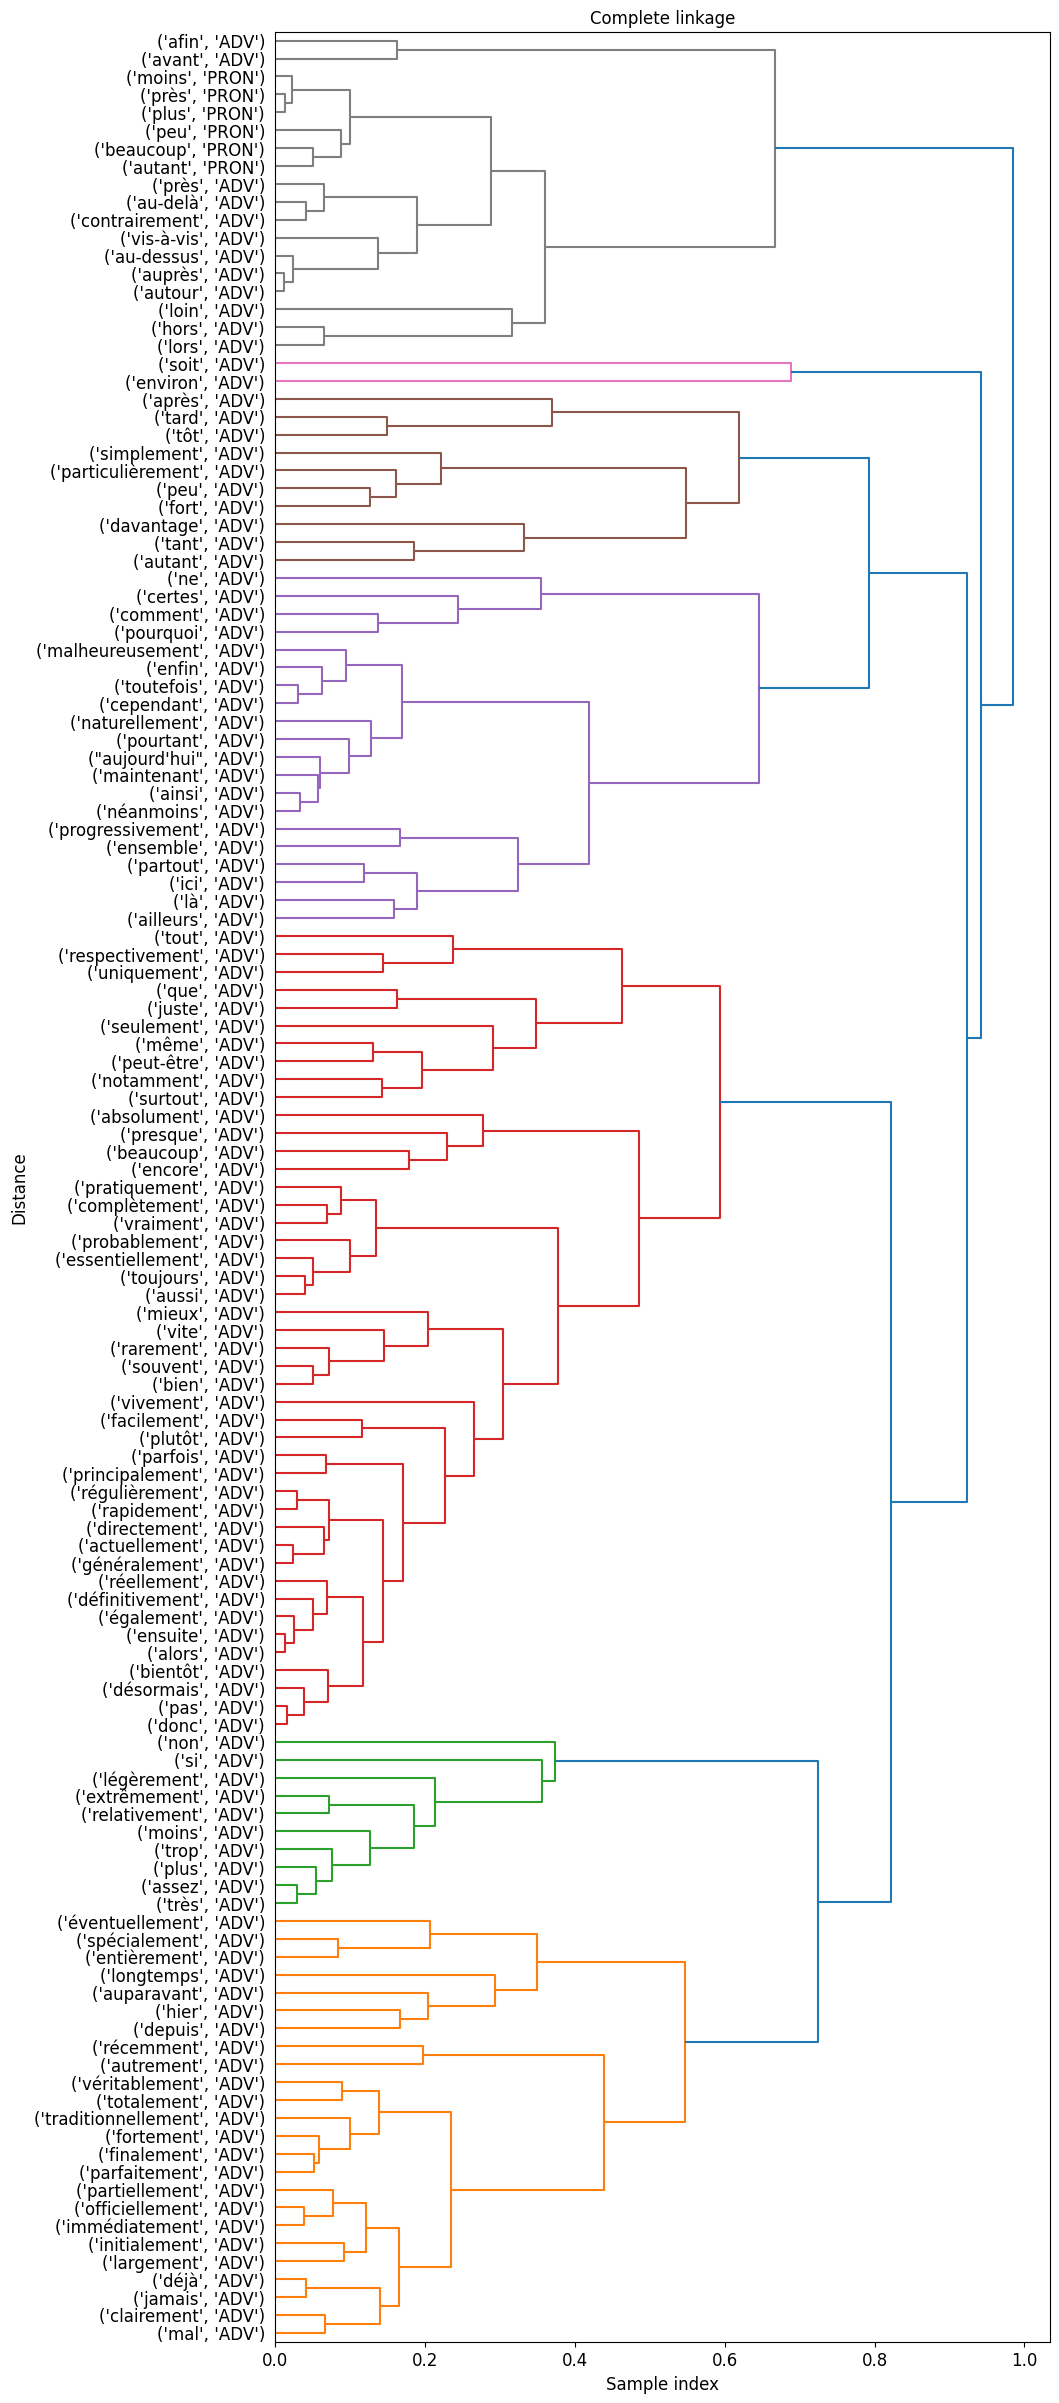

In [5]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib as plt
import matplotlib.pyplot as plt

distance_matrix = pdist(X, metric="cosine")
linked = linkage(
            distance_matrix, method="complete", optimal_ordering=True
        ) 

plt.figure(figsize=(10, 30))

dn = dendrogram(linked,
                orientation='right',
                labels=[corpus.idx2lexunit(i) for i in range(X.shape[0])],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Complete linkage', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

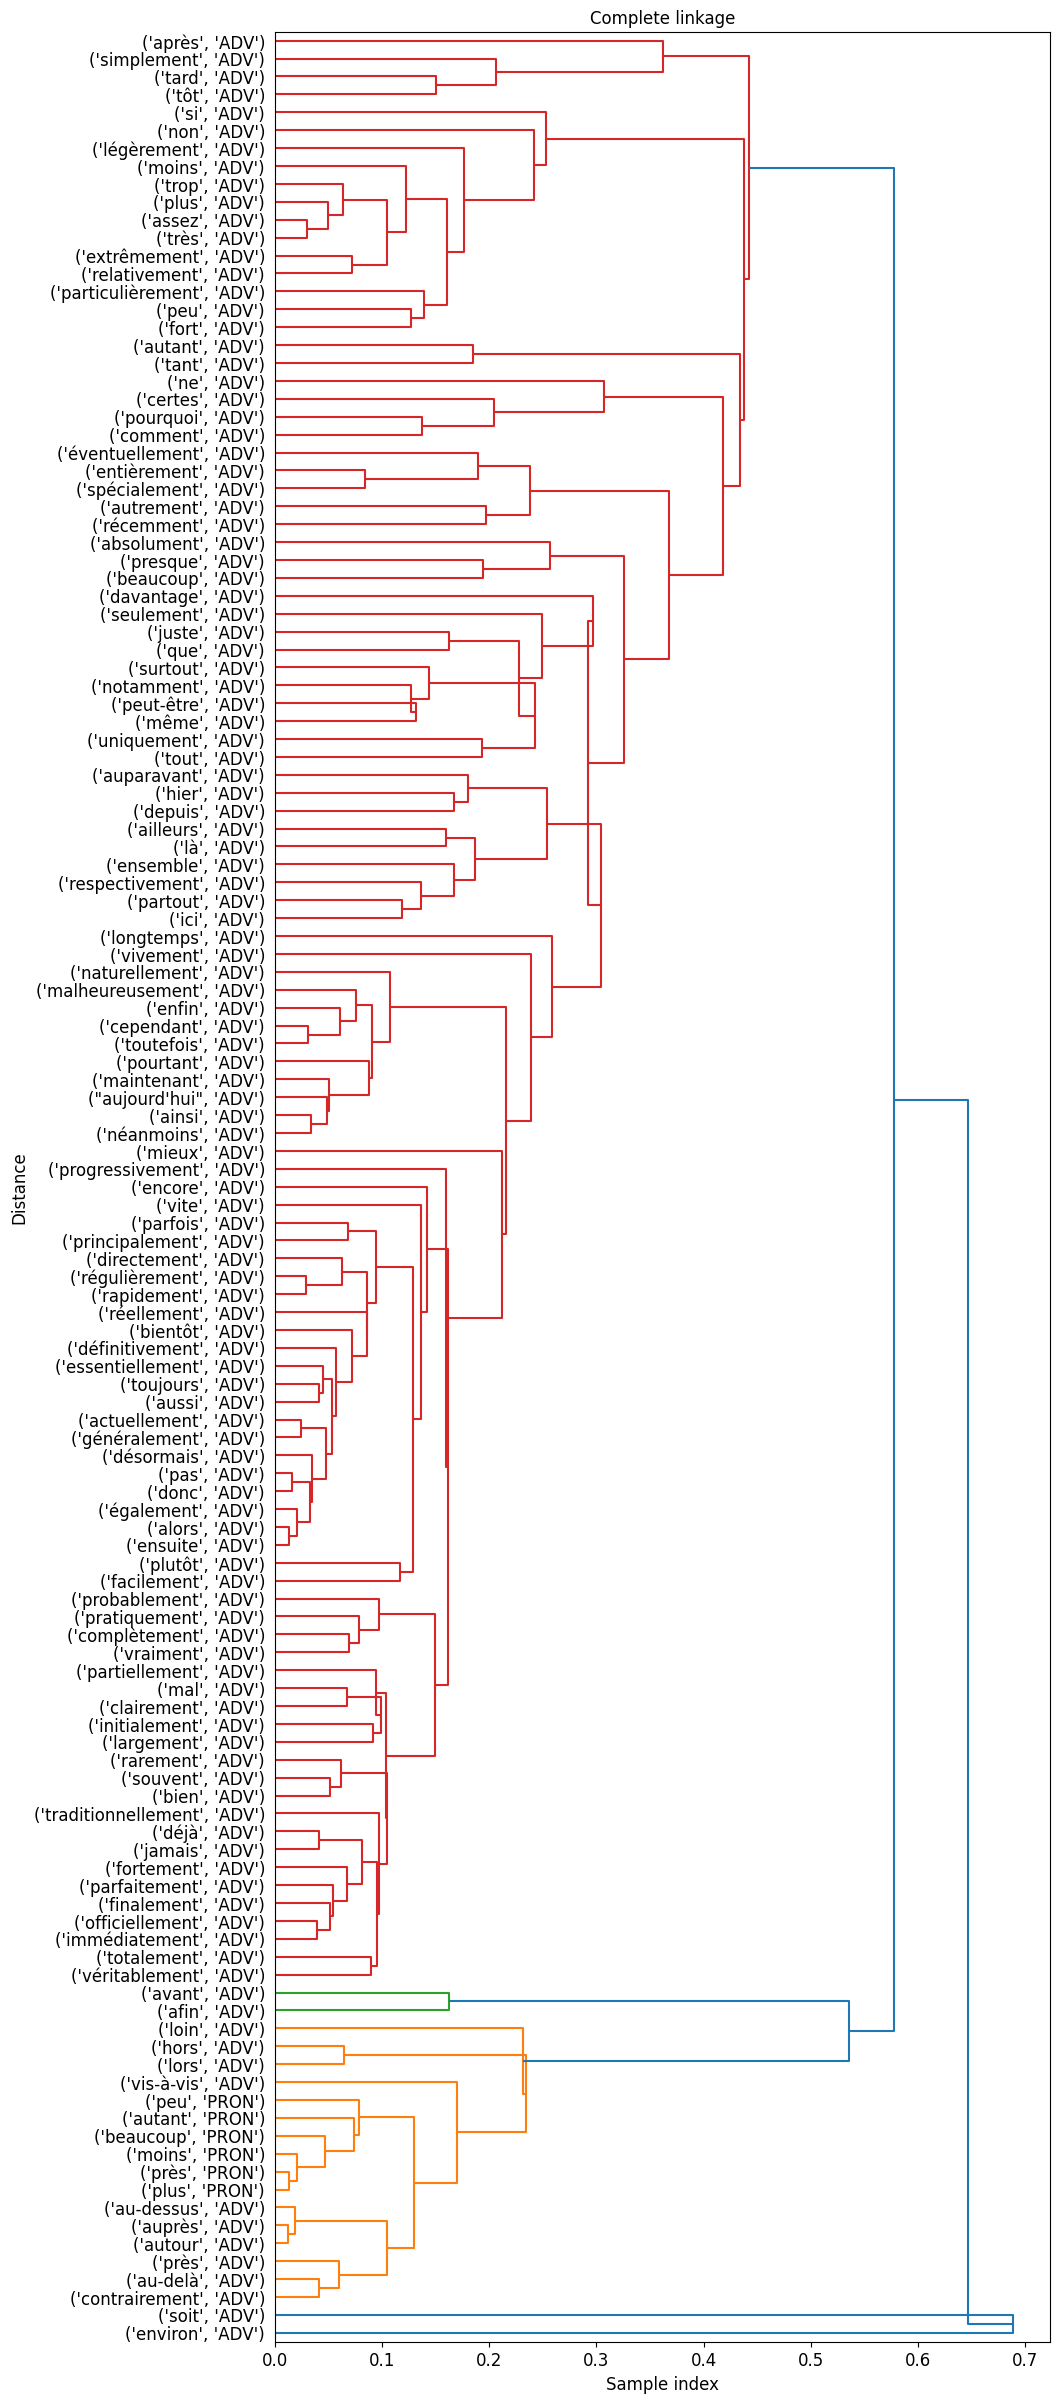

In [9]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib as plt
import matplotlib.pyplot as plt

distance_matrix = pdist(X, metric="cosine")
linked = linkage(
            distance_matrix, method="centroid", optimal_ordering=True
        ) 

plt.figure(figsize=(10, 30))

dn = dendrogram(linked,
                orientation='right',
                labels=[corpus.idx2lexunit(i) for i in range(X.shape[0])],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Complete linkage', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

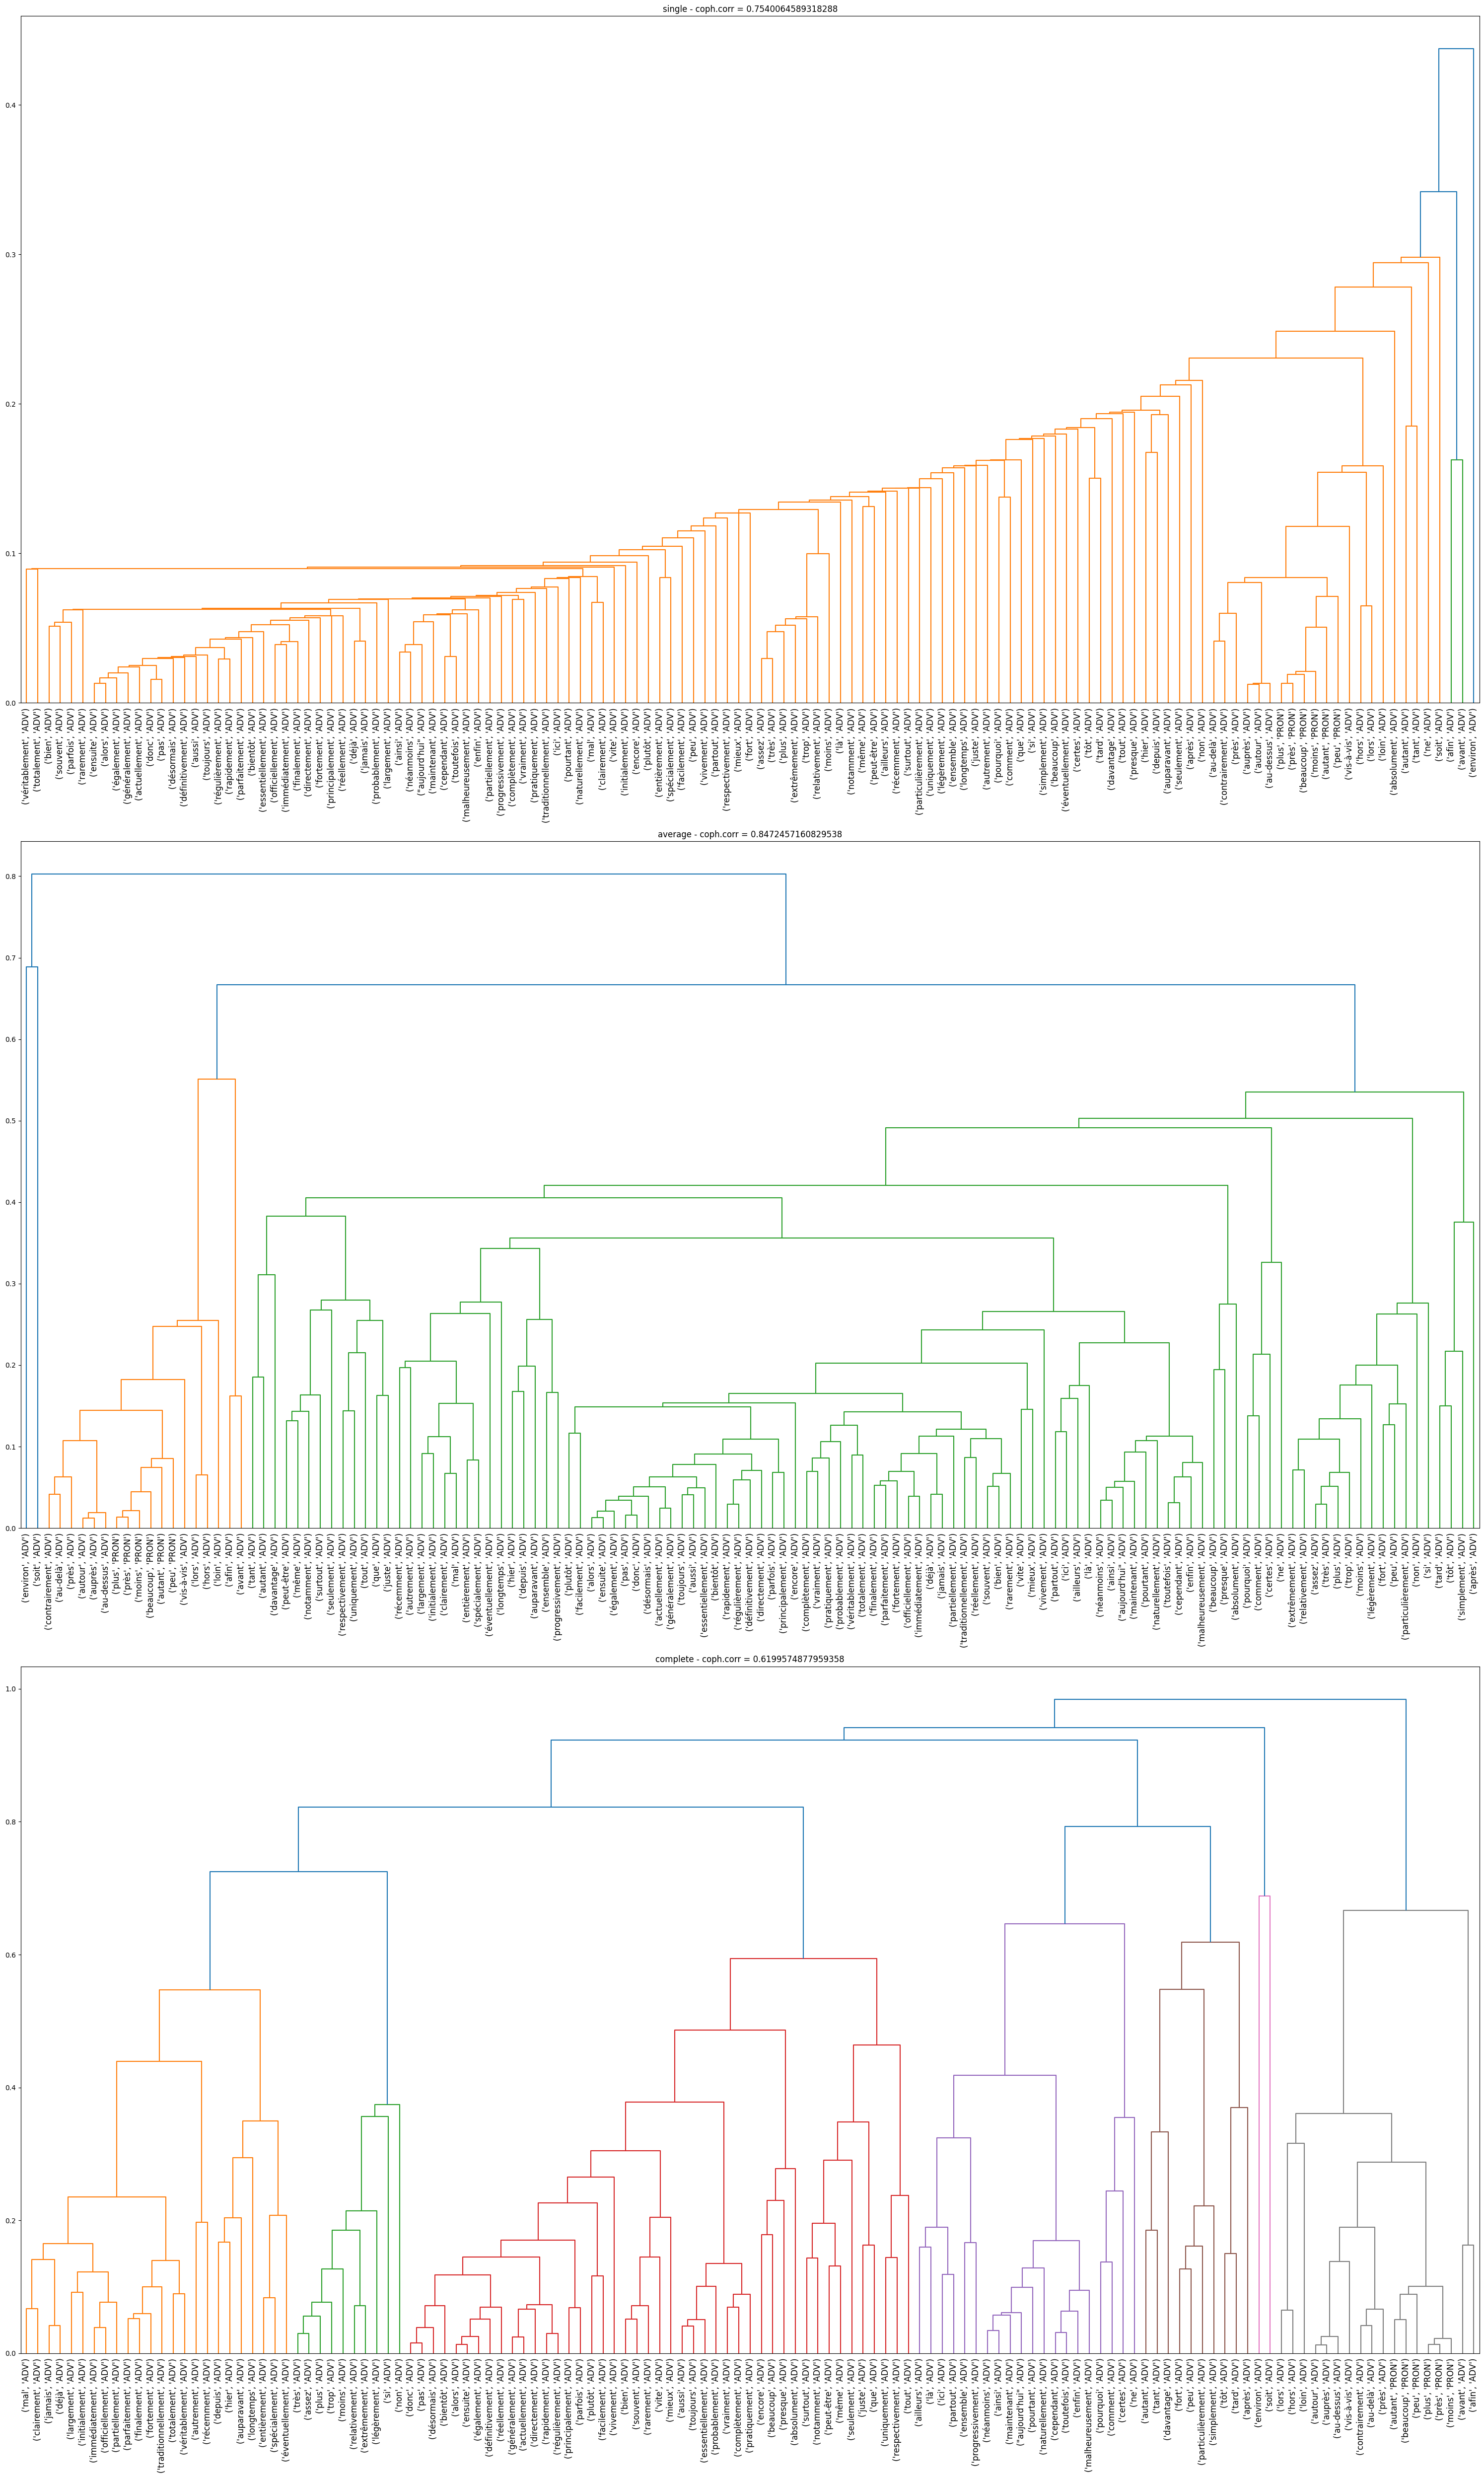

In [25]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet

fig, ax = plt.subplots(3, 1, figsize=(30, 50))
# link = ['single', 'average', 'ward', 'complete', 'centroid']
link = ['single', 'average', 'complete']

distance_matrix = pdist(X, metric="cosine")
for i in range(len(link)):
    linked = linkage(
            distance_matrix, method=link[i], optimal_ordering=True
        )
    dn = dendrogram(linked,
                    orientation='top',
                    labels=[corpus.idx2lexunit(i) for i in range(X.shape[0])],
                    distance_sort='descending',
                    show_leaf_counts=True,
                    get_leaves=True,
                    leaf_font_size=12,
                    ax=ax[i])
    ax[i].set_title(f"{link[i]} - coph.corr = {cophenet(linked, distance_matrix)[0]}" , fontsize=12)  # Increase title font size


fig.tight_layout()
plt.show() 

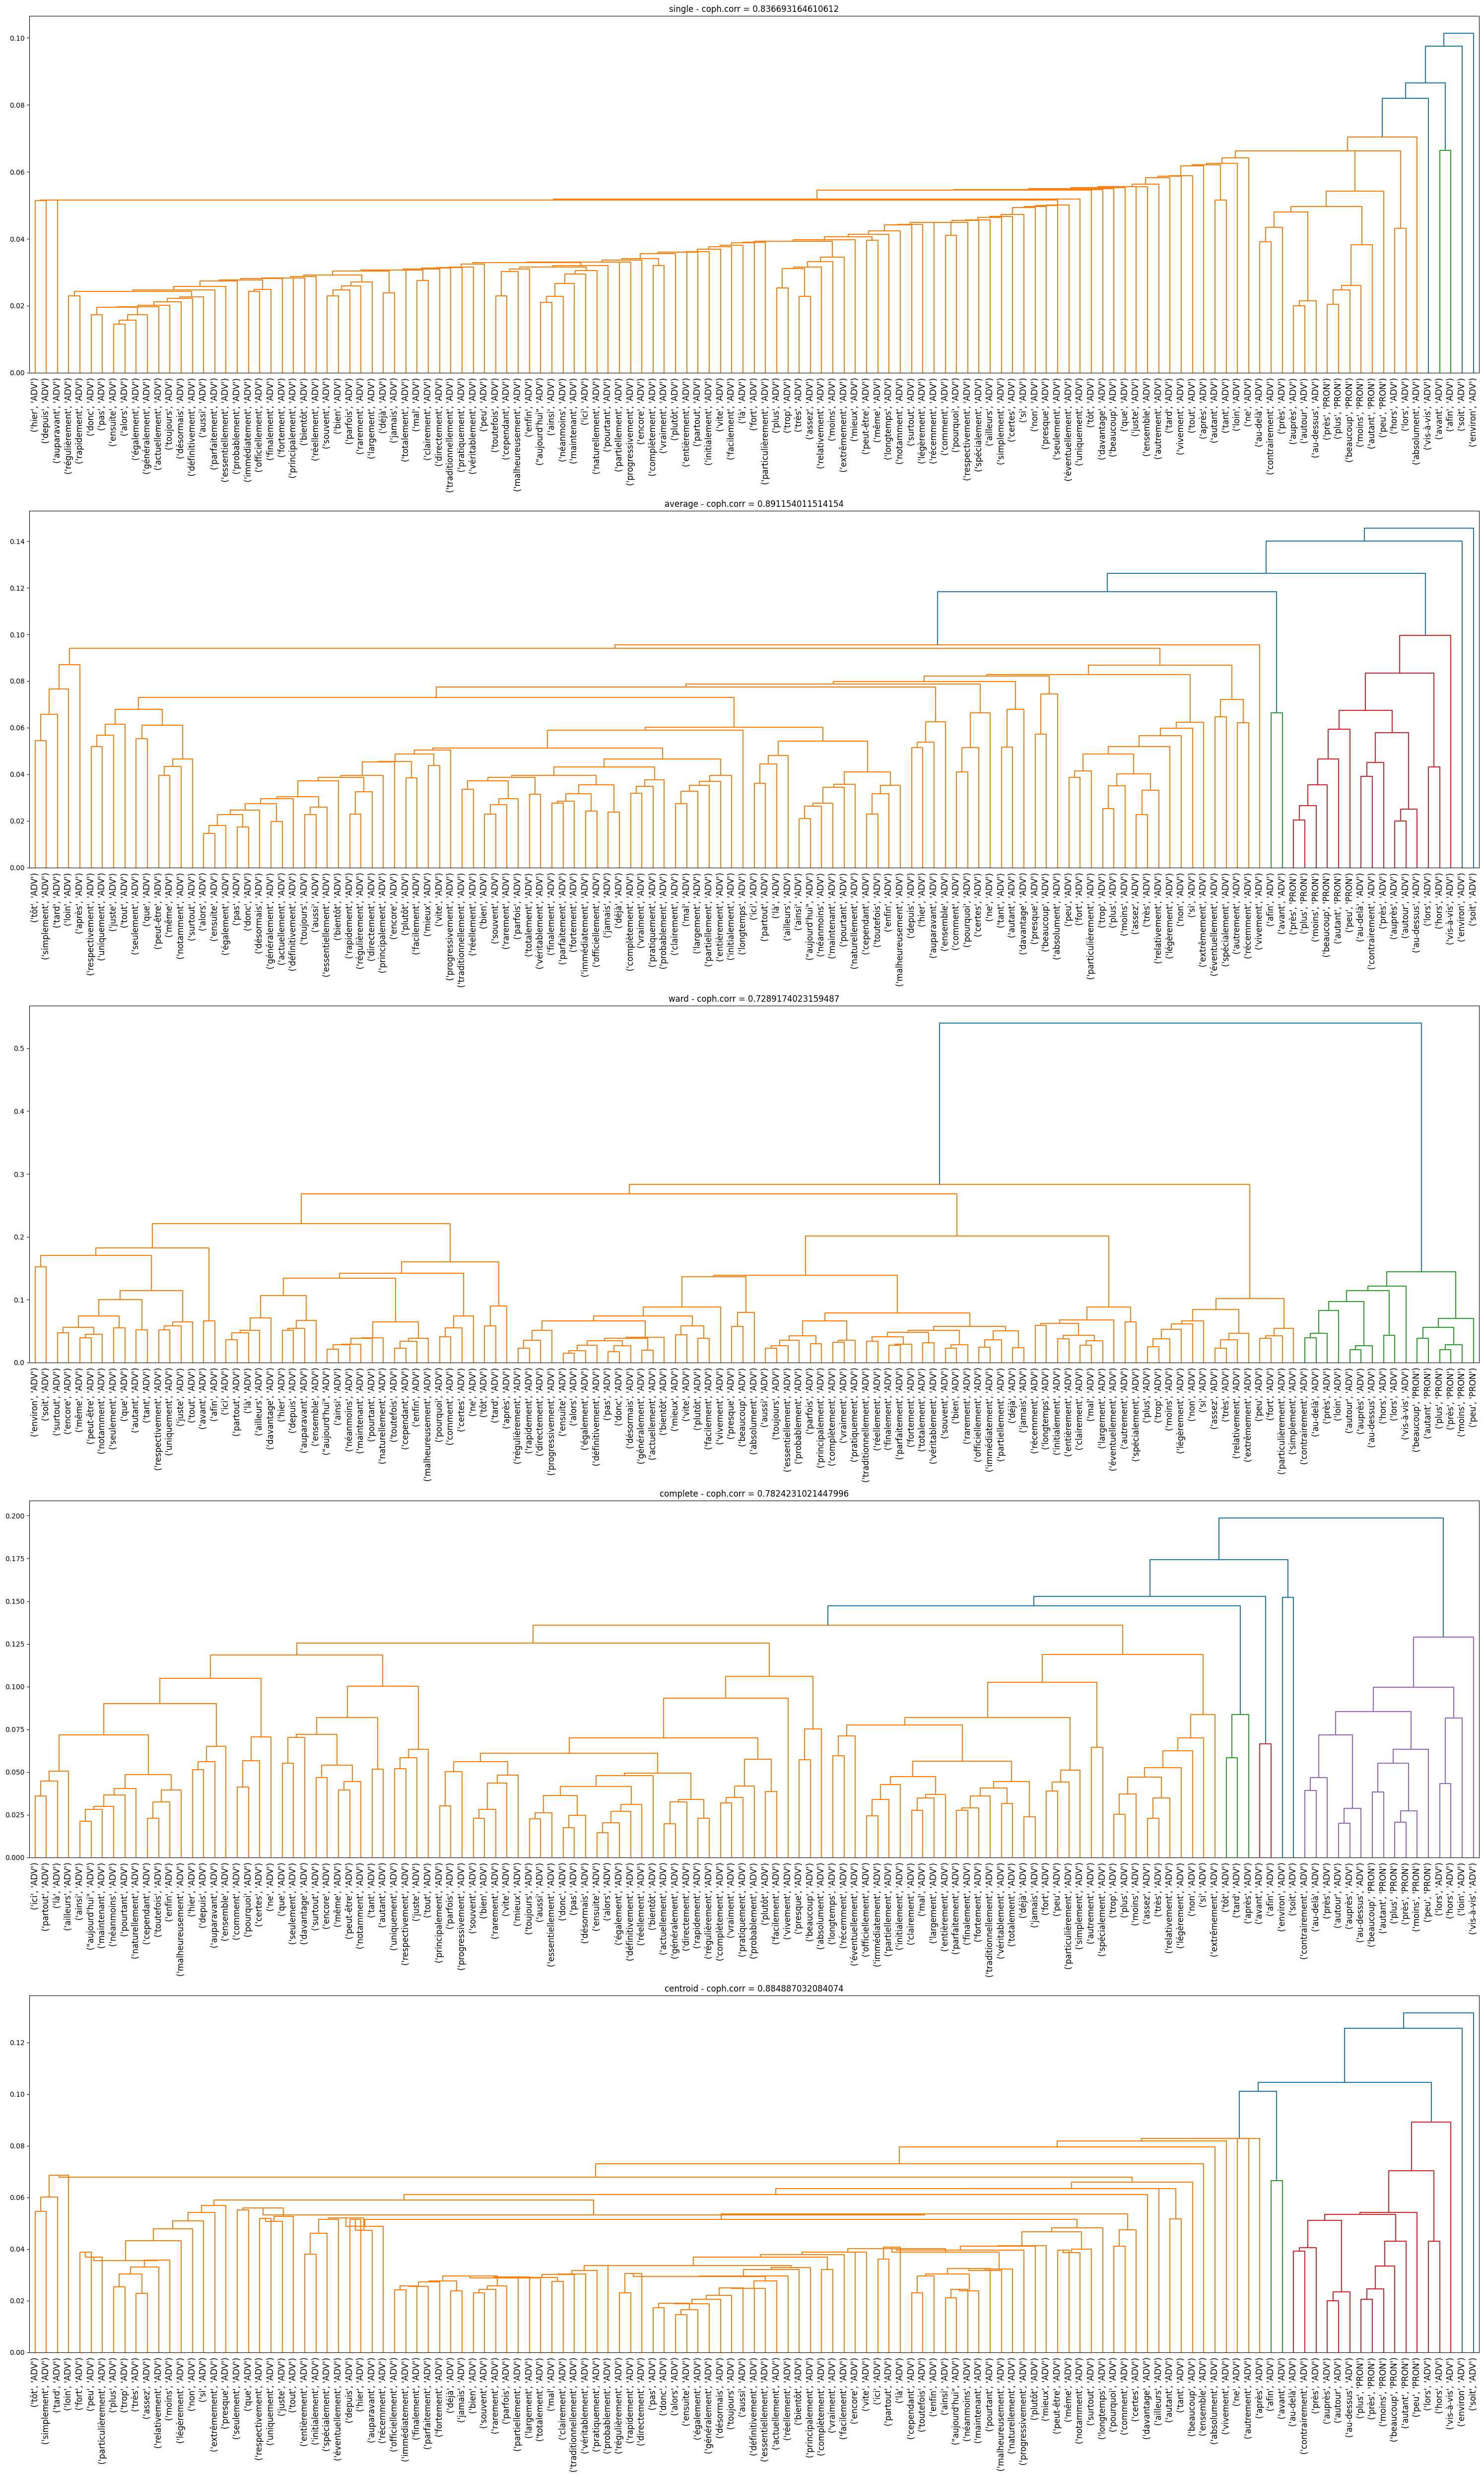

In [26]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet

fig, ax = plt.subplots(5, 1, figsize=(30, 50))
link = ['single', 'average', 'ward', 'complete', 'centroid']


distance_matrix = pdist(X, metric="euclidean")
for i in range(len(link)):
    linked = linkage(
            distance_matrix, method=link[i], optimal_ordering=True
        )
    dn = dendrogram(linked,
                    orientation='top',
                    labels=[corpus.idx2lexunit(i) for i in range(X.shape[0])],
                    distance_sort='descending',
                    show_leaf_counts=True,
                    get_leaves=True,
                    leaf_font_size=12,
                    ax=ax[i])
    ax[i].set_title(f"{link[i]} - coph.corr = {cophenet(linked, distance_matrix)[0]}" , fontsize=12)  # Increase title font size


fig.tight_layout()
plt.show() 

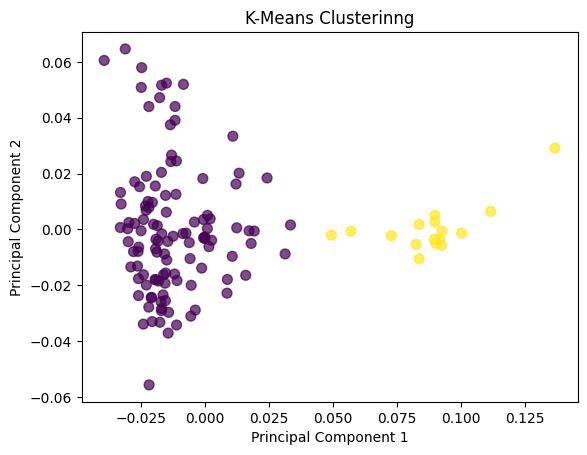

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
from sklearn.decomposition import PCA

# Perform K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)  # Adjust n_clusters as needed
labels = kmeans.fit_predict(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
# Visualize the clusters (using PCA for 2D projection)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

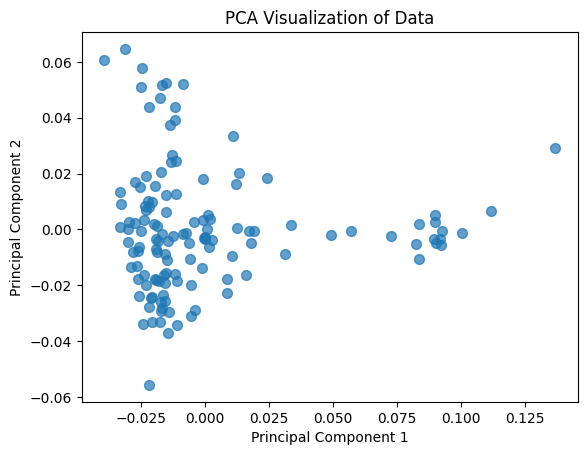

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA to reduce dimensions to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot the reduced data
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=50, alpha=0.7)
plt.title("PCA Visualization of Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

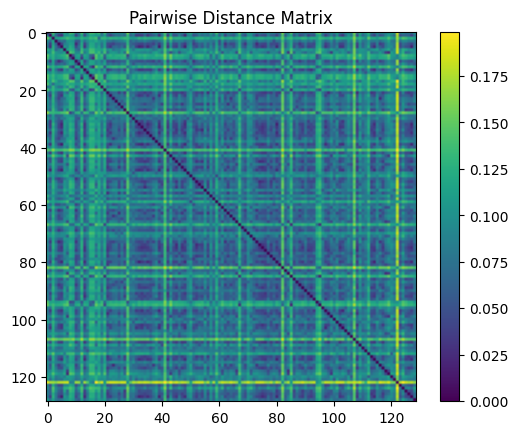

In [31]:
from scipy.spatial.distance import pdist, squareform

# Compute pairwise distances
distance_matrix = pdist(X, metric="euclidean")
distance_matrix_square = squareform(distance_matrix)

# Visualize the distance matrix
plt.imshow(distance_matrix_square, cmap='viridis')
plt.colorbar()
plt.title("Pairwise Distance Matrix")
plt.show()